# Deutschlandticket Analysis

Goal: Explore and analyse how attractive public transport options and adopting the Deutschlandticket would be for employees commuting to a hypothetical workplace in Hamburg, hereafter referred to as `workplace`.

### 0. Summary

- Only about 7% of mock employees have a public-transport commute of less than 30 minutes, approximately 24% commute within 45 minutes, and around half commute for more than 60 minutes one way. (see figure 5)

- Assuming that a public transport adoption score of 0.5 or higher indicates potential Deutschlandticket adoption, the estimated adoption potential is approximately 55% (see figure 7). but: public transport adoption depends on many factors and the comprehensive score created here based on detailed route data is by no means authoritative.

- The fact that the bus stops near the `workplace` are served by only two bus routes represents a major obstacle to widespread public-transport adoption. 

In [1]:
# ------------------------------------------------------------
# import libraries
# ------------------------------------------------------------
import geopandas as gpd
import importlib
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# import commute_analysis modules
# ------------------------------------------------------------

import commute_analysis.config as config
import commute_analysis.notebook_utils as notebook_utils
from commute_analysis.notebook_utils import prepare_probability_grid, to_gpd_point
import commute_analysis.visualization as viz
import commute_analysis.geometry as geometry
import commute_analysis.routing as routing
import commute_analysis.scoring as scoring

importlib.reload(config)
importlib.reload(notebook_utils)
prepare_probability_grid = notebook_utils.prepare_probability_grid
importlib.reload(viz)
importlib.reload(scoring)
importlib.reload(geometry)
importlib.reload(routing)

PROJECT_ROOT = config.PROJECT_ROOT
WORKPLACE = config.WORKPLACE

### 1. Synthetic mock employee data generation

Mock employee `home` locations are randomly sampled based on census data filtered <sup><a href="#fn1">1</a></sup> using a Gaussian filter centered on the `workplace`. The assumption is that employees are most likely to be found in high-density areas close to the `workplace`. The synthetic sample is loaded below and shown with the probability density used for sampling.

<p id="fn1"><sup>1</sup> source: 2022 census https://www.destatis.de/static/DE/zensus/gitterdaten/ </p>

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

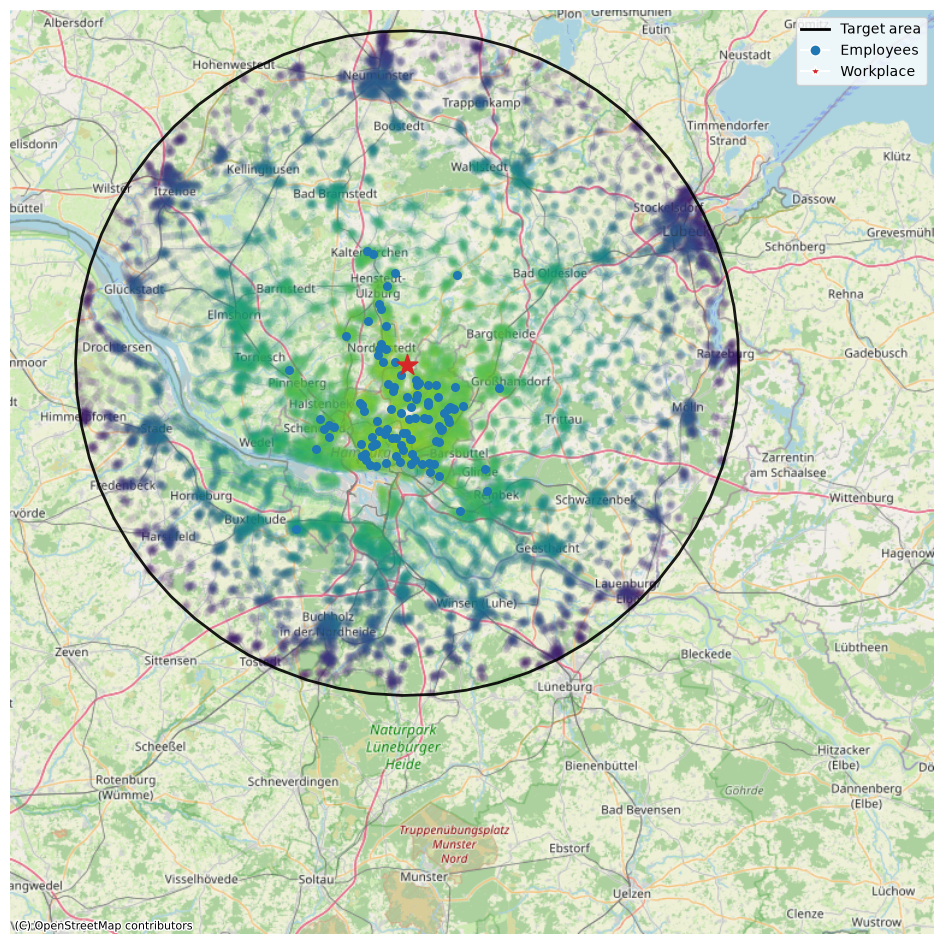

In [2]:
# ------------------------------------------------------------
# load synthetic mock employee data
# ------------------------------------------------------------

synthetic_employees = gpd.read_file(
    config.SYNTHETIC_EMPLOYEES_PATH,
    layer=config.SYNTHETIC_EMPLOYEES_LAYER,
)

# ------------------------------------------------------------
# define target area and generate probability density grid
# ------------------------------------------------------------

target_area = geometry.create_target_area(
    WORKPLACE[0],
    WORKPLACE[1],
    config.ANALYSIS_RADIUS_KM,
)
probability_grid = prepare_probability_grid(target_area)

# ------------------------------------------------------------
# plot mock employees and probability grid
# ------------------------------------------------------------

norm = LogNorm(
    vmin=probability_grid['sampling_probability'].min(),
    vmax=probability_grid['sampling_probability'].max(),
)

viz.plot_sampling_probability_map(
    probability_grid,
    target_area=target_area,
    employees=synthetic_employees,
    workplace=WORKPLACE,
    backend="matplotlib",
    figsize=(14, 12),
    add_basemap=True,
    probability_norm=norm,
    probability_alpha=0.025,
    employee_alpha=1,
    show_colorbar=False,
    employee_markersize=30,
)

Figure 1: mock employee `home` locations (blue dots), `workplace` (star), and probability density used for sampling (color overlay, yellow = high probability) shown on shown on an OpenStreetMap-based map of the area around Hamburg 

### 2. Visual public transport utility assessment

For an initial assessment, isochrones are computed around the `workplace`. They represent the boudaries which can be reached from the `workplace` in a given `time` via public transport. To construct these isochrones the r5py package <sup><a href="#fn1">2</a></sup> is used to build a `transport_network` based on OpenStreetMap (OSM) data <sup><a href="#fn1">3</a></sup> and HVV public-transport schedules <sup><a href="#fn1">4</a></sup>. This allows us to visualize the area that is reachable within 15, 30, 45, or 60 minutes from the `workplace` as shown in figure 2 and the folium map figure 3. The shown isochrones represent the optimal door-to-door commute time via public transport options averaged over a window of 60 minutes. 

<p id="fn1"><sup>2</sup> source: https://r5py.readthedocs.io/stable/  </p>
<p id="fn1"><sup>3</sup> source: https://download.geofabrik.de/europe/germany.html  </p>
<p id="fn1"><sup>4</sup> source: https://suche.transparenz.hamburg.de/dataset/hvv-fahrplandaten-gtfs-april-2026-bis-dezember-2026  </p>

/home/moritz/pythonproj/deticket/deutschlandticket_commute_analysis/.venv/lib/python3.14/site-packages/r5py/r5/transport_network.py:266: RuntimeWarning: R5 reported the following issues with GTFS file hvv_Rohdaten_GTFS_Fpl_26.ZIP: 
EmptyTableError: frequencies line 0: Table is present in zip file, but it has no entries.
  warnings.warn(


<Axes: title={'center': 'Public transport isochrones around workplace'}, xlabel='Easting [metre]', ylabel='Northing [metre]'>

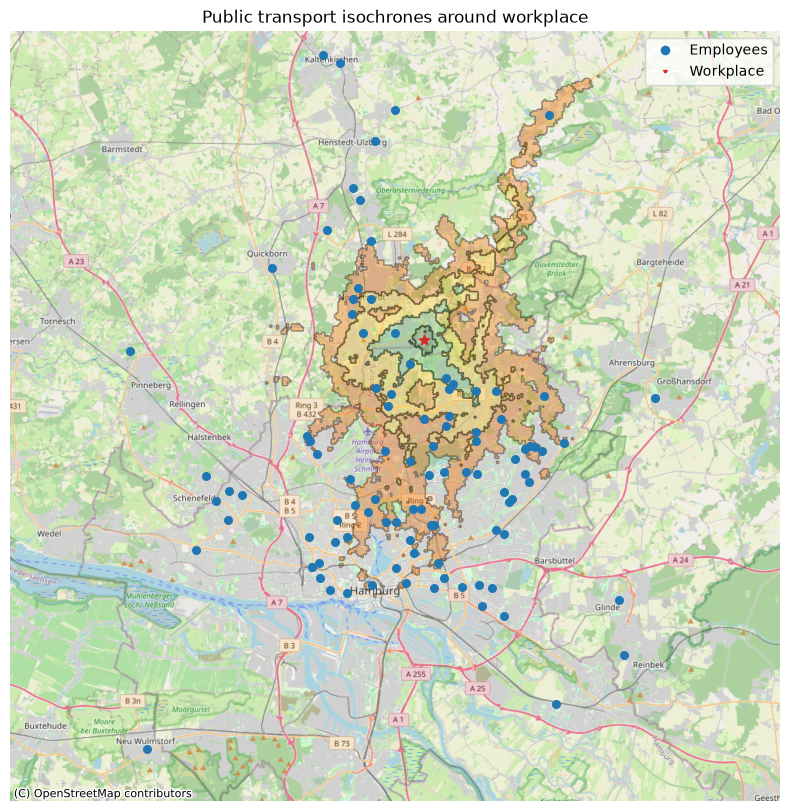

In [3]:
# ------------------------------------------------------------
# generate transport network
# ------------------------------------------------------------

transport_network = routing.build_transport_network(
    data_dir=config.OSM_DATA_DIR,
    allow_errors=config.ALLOW_ROUTING_DATA_ERRORS,
)

# ------------------------------------------------------------
# compute workplace reachability via public transport
# ------------------------------------------------------------

reachable = routing.calculate_reachable_grid(
    transport_network,
    to_gpd_point(WORKPLACE),
    config.ANALYSIS_ISOCHRONE_DEPARTURE,
    departure_time_window=config.REACHABILITY_TIME_WINDOW,
    analysis_radius_m=config.ANALYSIS_REACHABILITY_RADIUS_M,
    grid_step_m=config.REACHABILITY_GRID_STEP_M,
    max_travel_time_min=config.MAX_REACHABILITY_TIME_MIN,
)

# ------------------------------------------------------------
# plot isochrones, workplace, and employee home locations
# ------------------------------------------------------------

viz.plot_commute_map(
    reachable=reachable,
    workplace=WORKPLACE,
    employees=synthetic_employees,
    show_isochrones=True,
    employee_alpha=1,
    show_colorbar=False,
    employee_markersize=30,
    backend="matplotlib",
    title="Public transport isochrones around workplace",
)

Figure 2: mock employee `home` locations (blue dots), `workplace` (star), and isochrones around `workplace` shown on (osm based) map of the area around Hamburg; 
(dark green: <15 min, light green: <30 min, yellow. <45 min, orange: <60 min, no color: >60 min)

In [4]:
# ------------------------------------------------------------
# show isochrones, workplace, and employee home locations in interactive map
# ------------------------------------------------------------

isochrone_map = viz.plot_commute_map(
    reachable=reachable,
    workplace=WORKPLACE,
    employees=synthetic_employees,
    show_isochrones=True,
    backend="folium",
)
isochrone_map.save(config.ISOCHRONE_MAP_PATH)
isochrone_map

Figure 3: same as figure 2 but using interactive folium map 

These Isochrone plots provide us with a decent idea of the commute times using public transport for the employees. However, an exact commute-time analysis, including additional factors relevant to Deutschlandticket adoption, requires the calculation of individual commute routes for each employee.

### 3. Detailed commute analysis

The r5py `transport_network` also allows us to find the exact commute times and routes from the `home`locations to the `workplace` and back, at any specified time. As an example, figure 4 shows the fastest commute route for one employee using public transport options.

In [5]:
# ------------------------------------------------------------
# calculate public transport routes (morning and evening) for employee 1
# ------------------------------------------------------------

_, _, route_morning = routing.route_between_points(
    synthetic_employees.iloc[1].geometry,
    WORKPLACE,
    transport_modes=["public_transit"],
    data_dir=config.OSM_DATA_DIR,
    crs=synthetic_employees.crs,
    departure_time=config.EXAMPLE_MORNING_DEPARTURE,
)
_, _, route_evening = routing.route_between_points(
    WORKPLACE,
    synthetic_employees.iloc[1].geometry,
    transport_modes=["public_transit"],
    data_dir=config.OSM_DATA_DIR,
    crs=synthetic_employees.crs,
    departure_time=config.EXAMPLE_EVENING_DEPARTURE,
)

# ------------------------------------------------------------
# folium map of public transport commute route
# ------------------------------------------------------------

route_map = viz.plot_commute_map(
    routes=[route_morning, route_evening],
    workplace=WORKPLACE,
    employees=synthetic_employees[1:2],
    show_isochrones=True,
    backend="folium",
    show_route_segment_labels=True,
    route_color_strategy="mode",
    route_alpha=1,
    route_linewidth=5,
    add_basemap=True,
)
route_map.save(config.ROUTE_MAP_PATH)
route_map

Figure 4: folium map showing route from `home`to `workplace` using public transport options for employee 1 at `time = 08:00` as well as the return trip back `home` at `time = 17:15`; different legs of the trip using different modes of travel are indicated by different colors.

This allows us to create a histogram of the estimated commute times for the synthetic employee sample shown in figure 5.

<p id="fn1"><sup>5</sup> For the commute time estimate, the 25th percentile of fastest commute times in the morning and evening observation windows is used to avoid biasing toward single outliers.</p>

<Axes: xlabel='commute time (min)', ylabel='# employees'>

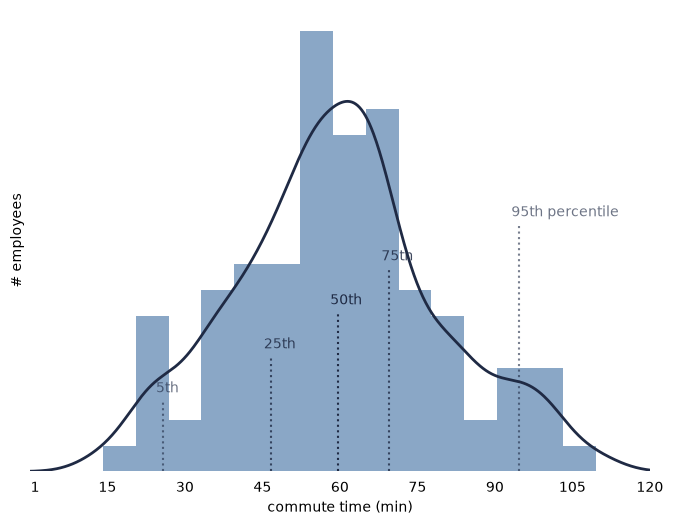

In [6]:
# ------------------------------------------------------------
# load preprocessed commute data of all employees
# ------------------------------------------------------------

score_df, route_df = scoring.load_transport_scores_from_gpkg(
    save_dir=config.TRANSPORT_SCORE_OUTPUT_DIR,
)

# ------------------------------------------------------------
# plot histogram of employee commute times (average one way)
# ------------------------------------------------------------

viz.plot_histogram(
    score_df.total_travel_time / 2,
    figsize=(8, 6),
    xlabel="commute time (min)",
    ylabel="# employees",
    kde_bw_method=0.25,
    x_ticks=[1, 15, 30, 45, 60, 75, 90, 105, 120],
    xlim=(0, 120),
)

Figure 5: histogram of employee commute times

### 4. Constructing a comprehensive "public transport adoption score"

Public transport adoption depends on many factors besides commute time (see e.g. "Factors that make public transport systems attractive: a review of travel preferences and travel mode choices" by Göransson & Andersson <sup><a href="#fn1">6</a></sup>). With the detailed route information we can add some additional data points to contruct a more comprehensive metric. Besides (A) the total commute time, we also consider:

(B) the commute time relative to the alternative of going by car;

(C) the consitency of service, measured by comparing the 25th percentile of commute times to the 75th percentile in the 2h morning and evening observation time window;

(D) the walking time involved in the public transport route;

(E) the number of transfers necessary as part of the route;

Based on these metrics, a "public transport adoption score" ranging from 0 to 1 is calculated. Figure 6 shows a histogram of the resulting scores, while figure 7 displays the results for each employee on the map.

<p id="fn1"><sup>6</sup> source: https://link.springer.com/article/10.1186/s12544-023-00609-x  </p>

<Axes: xlabel='public transport adoption score', ylabel='# employees'>

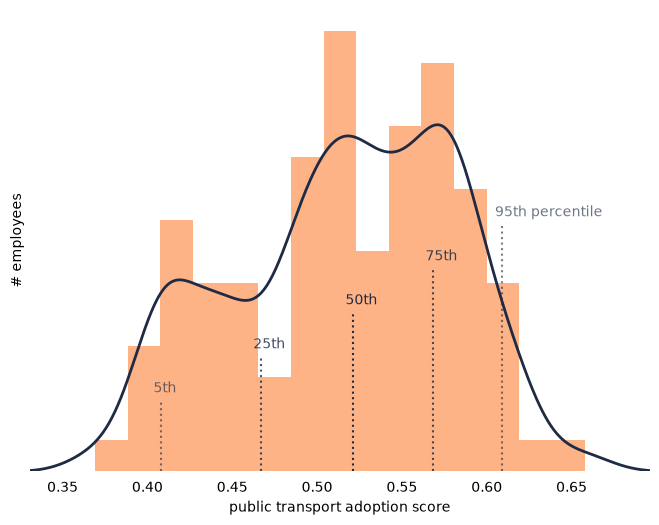

In [7]:
# ------------------------------------------------------------
# plot histogram of employee "public transport adoption score"
# ------------------------------------------------------------

viz.plot_histogram(
    score_df.transport_score,
    figsize=(8, 6),
    xlabel="public transport adoption score",
    ylabel="# employees",
    hist_color="#fc8b44",
    kde_bw_method=0.25,
)

Figure 6: histogram of employee "public transport adoption score"

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

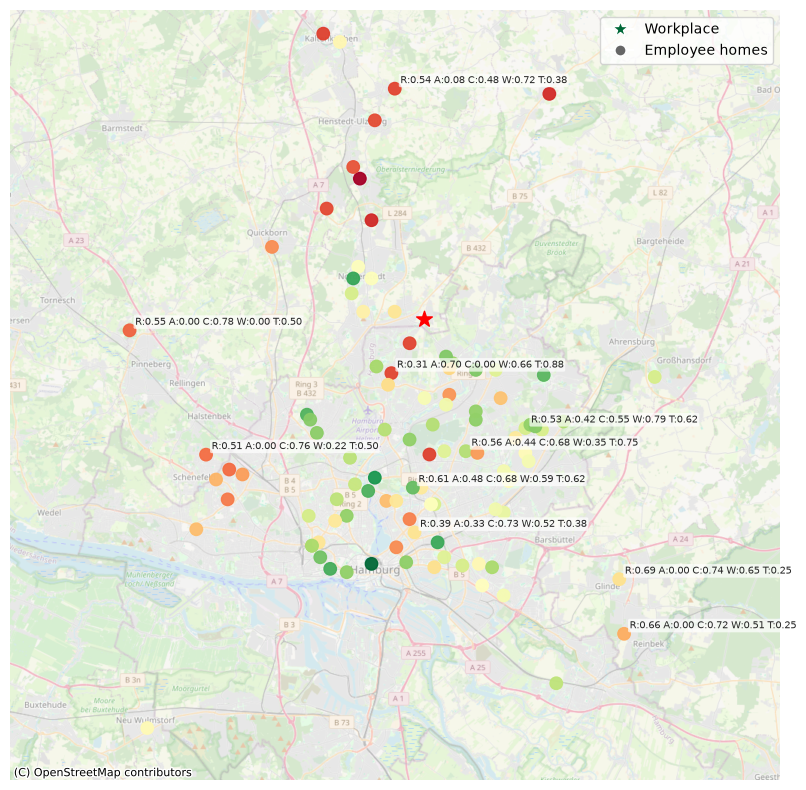

In [8]:
viz.plot_transport_score_routes(
    summary_gdf=score_df,
    workplace=WORKPLACE,
    add_basemap=True,
    fit_bounds=True,
    fit_bounds_padding_fraction=0.02,
    home_markersize=80,
    workplace_markersize=140,
    score_cmap="RdYlGn",
    show_colorbar=False,
    colorbar_label="Transport score",
    label_every_nth_home=10,
)

Map of employees’ public-transport adoption scores, indicated by colour, with green representing higher scores. Selected home locations are labelled with the five component scores: relative travel time (R), absolute travel time (A), consistency (C), walking time (W), and number of transfers (T).

This score analysis reveals further intricacies in the data. Even employees living close to the workplace might not want to adopt public transport options if the connection is inconsitent or involves much walking, whereas employees far from the workplyce with long commute times might still opt for public transport when the car alternative would also be lengthy.

### 5. Limitations

The weights and formulas for the differnt score components are somewhat arbitrary and can be found in `/src/commute_analysis/scoring.py`. Further relevant aspects of public transport adoption, like price, puctuality, ease of travel could not be assessed based on the utilized data.